In [ ]:
# Install required packages
!pip install google-cloud-bigquery google-cloud-storage pandas requests google-cloud-aiplatform

# Import libraries
import pandas as pd
import requests
import json
import time
from datetime import datetime
from google.cloud import bigquery, storage
import vertexai
from vertexai.generative_models import GenerativeModel

In [ ]:
PROJECT_ID = "qwiklabs-gcp-04-af615cbd429c"
DATASET_ID = "airport_weather"
AIRPORTS_TABLE = "airports"
ALERTS_TABLE = "weather_alerts"
LOCATION = "US"
GCS_BUCKET = "labs.roitraining.com"
CSV_PATH = "data-to-ai-workshop/airports.csv"

In [ ]:
# Initialize clients
bq_client = bigquery.Client(project=PROJECT_ID)
storage_client = storage.Client(project=PROJECT_ID)

# Create dataset if it doesn't exist
dataset_id = f"{PROJECT_ID}.{DATASET_ID}"
dataset = bigquery.Dataset(dataset_id)
dataset.location = LOCATION
dataset = bq_client.create_dataset(dataset, exists_ok=True)
print(f"Dataset {dataset_id} created or already exists")

Dataset qwiklabs-gcp-04-af615cbd429c.airport_weather created or already exists


In [ ]:
def load_airports_to_bigquery():
    """Download airports.csv from GCS and load into BigQuery"""

    # Read CSV directly from GCS
    gcs_uri = f"gs://{GCS_BUCKET}/{CSV_PATH}"
    df = pd.read_csv(gcs_uri)

    print(f"Loaded {len(df)} airports from GCS")
    print(f"Columns: {df.columns.tolist()}")

    # Filter for large airports only
    df_large = df[df['type'] == 'large_airport'].copy()
    print(f"Filtered to {len(df_large)} large airports")

    # Create table schema
    table_id = f"{PROJECT_ID}.{DATASET_ID}.{AIRPORTS_TABLE}"

    # Configure load job
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        autodetect=True,
    )

    # Load to BigQuery
    job = bq_client.load_table_from_dataframe(
        df_large, table_id, job_config=job_config
    )
    job.result()  # Wait for job to complete

    print(f"Loaded {len(df_large)} rows to {table_id}")
    return df_large

# Execute
airports_df = load_airports_to_bigquery()
airports_df.head()

Loaded 82893 airports from GCS
Columns: ['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'continent', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'icao_code', 'iata_code', 'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords']
Filtered to 482 large airports
Loaded 482 rows to qwiklabs-gcp-04-af615cbd429c.airport_weather.airports


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
9630,3,AGGH,large_airport,Honiara International Airport,-9.428000,160.054993,28.0,OC,SB,SB-GU,Honiara,yes,AGGH,HIR,AGGH,NaN,NaN,https://en.wikipedia.org/wiki/Honiara_Internat...,Henderson Field
11967,67,AYPY,large_airport,Port Moresby Jacksons International Airport,-9.443380,147.220001,146.0,OC,PG,PG-NCD,Port Moresby,yes,AYPY,POM,AYPY,NaN,NaN,https://en.wikipedia.org/wiki/Jacksons_Interna...,NaN
12707,123,BIKF,large_airport,Keflavik International Airport,63.985001,-22.605600,171.0,EU,IS,IS-2,Reykjavík,yes,BIKF,KEF,BIKF,NaN,https://www.isavia.is/en/keflavik-airport,https://en.wikipedia.org/wiki/Keflav%C3%ADk_In...,"Keflavik Naval Air Station,REK"
20547,1717,CYEG,large_airport,Edmonton International Airport,53.309700,-113.580002,2373.0,NaN,CA,CA-AB,Edmonton,yes,CYEG,YEG,CYEG,CYEG,http://www.edmontonairports.com/,https://en.wikipedia.org/wiki/Edmonton_Interna...,NaN
20604,1770,CYHZ,large_airport,Halifax / Stanfield International Airport,44.880798,-63.508598,477.0,NaN,CA,CA-NS,Halifax,yes,CYHZ,YHZ,CYHZ,NaN,http://www.hiaa.ca/,https://en.wikipedia.org/wiki/Halifax_Internat...,Robert L. Stanfield International Airport


In [ ]:
# NWS API Functions (Corrected)

def get_nws_grid_point(lat, lon):
    """Get NWS grid point for coordinates"""
    url = f"https://api.weather.gov/points/{lat},{lon}"
    headers = {'User-Agent': 'Airport Weather Alert System'}

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        data = response.json()

        forecast_url = data['properties']['forecast']
        return forecast_url
    except Exception as e:
        print(f"Error getting grid point for {lat},{lon}: {e}")
        return None

def get_nws_forecast(forecast_url):
    """Get weather forecast from NWS"""
    headers = {'User-Agent': 'Airport Weather Alert System'}

    try:
        response = requests.get(forecast_url, headers=headers, timeout=10)
        response.raise_for_status()
        data = response.json()

        periods = data['properties']['periods']
        return periods[:3]  # Return next 3 periods (roughly 36 hours)
    except Exception as e:
        print(f"Error getting forecast: {e}")
        return None

def fetch_all_forecasts(airports_df):
    """Fetch forecasts for all large airports"""
    forecasts = []
    failed_count = 0

    for idx, row in airports_df.iterrows():
        airport_code = row['iata_code'] if 'iata_code' in row else row['ident']
        lat = row['latitude_deg']
        lon = row['longitude_deg']
        name = row['name']

        print(f"Fetching forecast for {airport_code} - {name}...")

        # Get forecast URL
        forecast_url = get_nws_grid_point(lat, lon)
        if not forecast_url:
            failed_count += 1
            continue

        # Get forecast
        time.sleep(0.5)  # Rate limiting
        forecast_periods = get_nws_forecast(forecast_url)
        if not forecast_periods:
            failed_count += 1
            continue

        forecasts.append({
            'airport_code': airport_code,
            'airport_name': name,
            'latitude': lat,
            'longitude': lon,
            'forecast_data': forecast_periods,
            'retrieved_at': datetime.now().isoformat()
        })

    print(f"\n{'='*60}")
    print(f"SUCCESS: Retrieved {len(forecasts)} forecasts")
    print(f"FAILED: {failed_count} airports")
    print(f"{'='*60}\n")

    return forecasts

# Filter for US airports only (NWS only covers US locations)
print(f"Total airports in dataset: {len(airports_df)}")
us_airports_df = airports_df[airports_df['iso_country'] == 'US'].copy()
print(f"Filtered to {len(us_airports_df)} US airports\n")

# Execute - fetch forecasts for US airports only
weather_forecasts = fetch_all_forecasts(us_airports_df)
print(f"\nFinal result: {len(weather_forecasts)} weather forecasts retrieved")


Total airports in dataset: 482
Filtered to 71 US airports

Fetching forecast for ABQ - Albuquerque International Sunport...
Fetching forecast for ADW - Joint Base Andrews...
Fetching forecast for ATL - Hartsfield Jackson Atlanta International Airport...
Fetching forecast for AUS - Austin Bergstrom International Airport...
Fetching forecast for BDL - Bradley International Airport...
Fetching forecast for BNA - Nashville International Airport...
Fetching forecast for BOS - Logan International Airport...
Fetching forecast for BUF - Buffalo Niagara International Airport...
Fetching forecast for BWI - Baltimore/Washington International Thurgood Marshall Airport...
Fetching forecast for CLE - Cleveland Hopkins International Airport...
Fetching forecast for CLT - Charlotte Douglas International Airport...
Fetching forecast for CMH - John Glenn Columbus International Airport...
Fetching forecast for CVG - Cincinnati Northern Kentucky International Airport...
Fetching forecast for DCA - Ronald 

In [ ]:
# Initialize Gemini
vertexai.init(project=PROJECT_ID, location="us-central1")
model = GenerativeModel("gemini-2.5-flash")

def generate_weather_alert(airport_code, airport_name, forecast_data):
    """Use Gemini to analyze forecast and generate alert"""

    # Format forecast for Gemini
    forecast_text = "\n".join([
        f"{period['name']}: {period['detailedForecast']}"
        for period in forecast_data
    ])

    prompt = f"""
    You are a weather analyst for aviation operations. Analyze this weather forecast for {airport_name} ({airport_code}) and generate a concise alert.

    FORECAST:
    {forecast_text}

    Create an alert that:
    1. Assigns a severity level (LOW, MODERATE, HIGH, CRITICAL)
    2. Highlights any conditions that could impact flight operations (wind, visibility, precipitation, storms)
    3. Provides a brief summary (2-3 sentences)
    4. Suggests any operational considerations

    Format your response as JSON:
    {{
        "severity": "MODERATE",
        "summary": "Brief summary here",
        "conditions": ["condition1", "condition2"],
        "recommendations": "Operational recommendations"
    }}
    """

    try:
        response = model.generate_content(prompt)
        alert_json = json.loads(response.text.strip().replace('```json', '').replace('```', ''))
        return alert_json
    except Exception as e:
        print(f"Error generating alert for {airport_code}: {e}")
        return {
            "severity": "UNKNOWN",
            "summary": "Unable to generate alert",
            "conditions": [],
            "recommendations": ""
        }

def generate_all_alerts(forecasts):
    """Generate alerts for all airports"""
    alerts = []

    for forecast in forecasts:
        print(f"Generating alert for {forecast['airport_code']}...")

        alert = generate_weather_alert(
            forecast['airport_code'],
            forecast['airport_name'],
            forecast['forecast_data']
        )

        alerts.append({
            'airport_code': forecast['airport_code'],
            'airport_name': forecast['airport_name'],
            'latitude': forecast['latitude'],
            'longitude': forecast['longitude'],
            'severity': alert['severity'],
            'summary': alert['summary'],
            'conditions': json.dumps(alert['conditions']),
            'recommendations': alert['recommendations'],
            'forecast_retrieved_at': forecast['retrieved_at'],
            'alert_generated_at': datetime.now().isoformat()
        })

        time.sleep(1)  # Rate limiting for Gemini

    return alerts

# Execute
alerts = generate_all_alerts(weather_forecasts)
print(f"Generated {len(alerts)} alerts")


/usr/local/lib/python3.12/dist-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Generating alert for ABQ...
Generating alert for ADW...
Generating alert for ATL...
Generating alert for AUS...
Generating alert for BDL...
Generating alert for BNA...
Generating alert for BOS...
Generating alert for BUF...
Generating alert for BWI...
Generating alert for CLE...
Generating alert for CLT...
Generating alert for CMH...
Generating alert for CVG...
Generating alert for DCA...
Generating alert for DEN...
Generating alert for DFW...
Generating alert for DTW...
Generating alert for EWR...
Generating alert for FLL...
Generating alert for IAD...
Generating alert for IAH...
Generating alert for IND...
Generating alert for JAX...
Error generating alert for JAX: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.
Generating alert for JFK...
Generating alert for LAS...
Generating alert for LAX...
Generating alert for LGA...
Generating alert for MCI...
Generating alert for MCO...
Gener

In [ ]:
# Delete the existing table
table_id = f"{PROJECT_ID}.{DATASET_ID}.{ALERTS_TABLE}"
bq_client.delete_table(table_id, not_found_ok=True)
print(f"Deleted table {table_id}")

# Now run your original function
def load_alerts_to_bigquery(alerts):
    """Load weather alerts to BigQuery"""

    df_alerts = pd.DataFrame(alerts)

    # Convert string timestamps to datetime
    df_alerts['forecast_retrieved_at'] = pd.to_datetime(df_alerts['forecast_retrieved_at'])
    df_alerts['alert_generated_at'] = pd.to_datetime(df_alerts['alert_generated_at'])

    table_id = f"{PROJECT_ID}.{DATASET_ID}.{ALERTS_TABLE}"

    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        autodetect=True,
    )

    job = bq_client.load_table_from_dataframe(
        df_alerts, table_id, job_config=job_config
    )
    job.result()

    print(f"Loaded {len(df_alerts)} alerts to {table_id}")

    # Print the detected schema for verification
    table = bq_client.get_table(table_id)
    print("\nDetected schema:")
    for field in table.schema:
        print(f"  {field.name}: {field.field_type}")

    return df_alerts

# Execute
alerts_df = load_alerts_to_bigquery(alerts)
alerts_df.head()



Deleted table qwiklabs-gcp-04-af615cbd429c.airport_weather.weather_alerts
Loaded 71 alerts to qwiklabs-gcp-04-af615cbd429c.airport_weather.weather_alerts

Detected schema:
  airport_code: STRING
  airport_name: STRING
  latitude: FLOAT
  longitude: FLOAT
  severity: STRING
  summary: STRING
  conditions: STRING
  recommendations: STRING
  forecast_retrieved_at: DATETIME
  alert_generated_at: DATETIME


,airport_code,airport_name,latitude,longitude,severity,summary,conditions,recommendations,forecast_retrieved_at,alert_generated_at
0,ABQ,Albuquerque International Sunport,35.039976,-106.608925,HIGH,ABQ will experience extremely high winds today...,"[""Strong Winds (gusts up to 60 mph)"", ""Severe ...","Pilots should anticipate severe turbulence, si...",2026-03-27 16:44:24.085749,2026-03-27 16:47:07.630923
1,ADW,Joint Base Andrews,38.810799,-76.866997,MODERATE,Joint Base Andrews will experience MODERATE op...,"[""Gusty Winds (up to 25 mph)"", ""Rain showers (...",Pilots should anticipate challenging crosswind...,2026-03-27 16:44:24.798570,2026-03-27 16:47:15.481350
2,ATL,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101,MODERATE,Aviation operations at ATL will experience inc...,"[""High winds"", ""Wind gusts""]",Pilots should anticipate moderate to strong cr...,2026-03-27 16:44:25.421531,2026-03-27 16:47:22.988417
3,AUS,Austin Bergstrom International Airport,30.197535,-97.662015,MODERATE,Aviation operations at AUS will be impacted by...,"[""Strong Gusty Winds"", ""Light Rain Showers""]",Pilots and ground crew should monitor wind spe...,2026-03-27 16:44:26.035780,2026-03-27 16:47:30.361359
4,BDL,Bradley International Airport,41.938510,-72.688066,MODERATE,Bradley International Airport (BDL) will exper...,"[""Strong Winds"", ""Wind Gusts""]",Operators should review aircraft-specific cros...,2026-03-27 16:44:26.668716,2026-03-27 16:47:36.766896


In [ ]:
# Check what columns exist in the airports table

table_id = f"{PROJECT_ID}.{DATASET_ID}.{AIRPORTS_TABLE}"
table = bq_client.get_table(table_id)

print("Airports table schema:")
for field in table.schema:
    print(f"  {field.name}: {field.field_type}")

# Also peek at the data
query = f"SELECT * FROM `{table_id}` LIMIT 5"
sample_df = bq_client.query(query).to_dataframe()
print("\nSample data:")
print(sample_df.head())


Airports table schema:
  id: INTEGER
  ident: STRING
  type: STRING
  name: STRING
  latitude_deg: FLOAT
  longitude_deg: FLOAT
  elevation_ft: FLOAT
  continent: STRING
  iso_country: STRING
  iso_region: STRING
  municipality: STRING
  scheduled_service: STRING
  icao_code: STRING
  iata_code: STRING
  gps_code: STRING
  local_code: STRING
  home_link: STRING
  wikipedia_link: STRING
  keywords: STRING

Sample data:
     id ident           type                                         name  \
0     3  AGGH  large_airport                Honiara International Airport   
1    67  AYPY  large_airport  Port Moresby Jacksons International Airport   
2   123  BIKF  large_airport               Keflavik International Airport   
3  1717  CYEG  large_airport               Edmonton International Airport   
4  1770  CYHZ  large_airport    Halifax / Stanfield International Airport   

   latitude_deg  longitude_deg  elevation_ft continent iso_country iso_region  \
0     -9.428000     160.054993    

In [ ]:
# Create view for Looker Studio

create_view_sql = f"""
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view` AS
SELECT
    COALESCE(a.iata_code, a.ident) as airport_code,
    a.name as airport_name,
    a.latitude_deg as latitude,
    a.longitude_deg as longitude,
    a.municipality as city,
    a.iso_country as country,
    a.iso_region as region,
    al.severity,
    al.summary,
    al.conditions,
    al.recommendations,
    al.alert_generated_at,
    al.forecast_retrieved_at,
    CASE
        WHEN al.severity = 'CRITICAL' THEN 1
        WHEN al.severity = 'HIGH' THEN 2
        WHEN al.severity = 'MODERATE' THEN 3
        WHEN al.severity = 'LOW' THEN 4
        ELSE 5
    END as severity_rank,
    CASE
        WHEN al.severity = 'CRITICAL' THEN '#DC3545'
        WHEN al.severity = 'HIGH' THEN '#FD7E14'
        WHEN al.severity = 'MODERATE' THEN '#FFC107'
        WHEN al.severity = 'LOW' THEN '#28A745'
        ELSE '#6C757D'
    END as severity_color
FROM `{PROJECT_ID}.{DATASET_ID}.{AIRPORTS_TABLE}` a
LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.{ALERTS_TABLE}` al
    ON (a.iata_code = al.airport_code OR a.ident = al.airport_code)
WHERE a.type = 'large_airport'
"""

bq_client.query(create_view_sql).result()
print("Created view for Looker Studio")


Created view for Looker Studio


In [ ]:
# Test the view

# Check row count and sample data
view_test_query = f"""
SELECT
    COUNT(*) as total_rows,
    COUNT(DISTINCT airport_code) as unique_airports,
    COUNT(CASE WHEN severity IS NOT NULL THEN 1 END) as airports_with_alerts
FROM `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view`
"""

test_results = bq_client.query(view_test_query).to_dataframe()
print("View statistics:")
print(test_results)

# Show sample data
sample_query = f"""
SELECT
    airport_code,
    airport_name,
    city,
    country,
    severity,
    summary,
    alert_generated_at
FROM `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view`
ORDER BY severity_rank, airport_name
LIMIT 10
"""

sample_df = bq_client.query(sample_query).to_dataframe()
print("\nSample view data:")
print(sample_df)


View statistics:
   total_rows  unique_airports  airports_with_alerts
0         482              482                    71

Sample view data:
  airport_code                                       airport_name  \
0          ABQ                  Albuquerque International Sunport   
1          MSP  Minneapolis–Saint Paul International Airport /...   
2          IAD            Washington Dulles International Airport   
3          OKC                          Will Rogers World Airport   
4          AUS             Austin Bergstrom International Airport   
5          BWI  Baltimore/Washington International Thurgood Ma...   
6          BDL                      Bradley International Airport   
7          BUF              Buffalo Niagara International Airport   
8          CLT            Charlotte Douglas International Airport   
9          MDW               Chicago Midway International Airport   

            city country  severity  \
0    Albuquerque      US      HIGH   
1    Minneapolis      

In [ ]:
# Check severity distribution for dashboard planning

severity_query = f"""
SELECT
    severity,
    COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
FROM `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view`
WHERE severity IS NOT NULL
GROUP BY severity
ORDER BY
    CASE
        WHEN severity = 'CRITICAL' THEN 1
        WHEN severity = 'HIGH' THEN 2
        WHEN severity = 'MODERATE' THEN 3
        WHEN severity = 'LOW' THEN 4
        ELSE 5
    END
"""

severity_dist = bq_client.query(severity_query).to_dataframe()
print("Severity distribution:")
print(severity_dist)


Severity distribution:
   severity  count  percentage
0      HIGH      4        5.63
1  MODERATE     51       71.83
2       LOW     15       21.13
3   UNKNOWN      1        1.41


In [ ]:
# Verify we have good geographic data for the map

geo_check_query = f"""
SELECT
    COUNT(*) as total_airports,
    COUNT(CASE WHEN latitude IS NOT NULL AND longitude IS NOT NULL THEN 1 END) as airports_with_coords,
    MIN(latitude) as min_lat,
    MAX(latitude) as max_lat,
    MIN(longitude) as min_lon,
    MAX(longitude) as max_lon
FROM `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view`
"""

geo_check = bq_client.query(geo_check_query).to_dataframe()
print("Geographic data check:")
print(geo_check)

# Show a few sample airports for map testing
map_sample_query = f"""
SELECT
    airport_code,
    airport_name,
    city,
    latitude,
    longitude,
    severity,
    severity_color
FROM `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view`
WHERE severity IS NOT NULL
ORDER BY severity_rank
LIMIT 5
"""

map_sample = bq_client.query(map_sample_query).to_dataframe()
print("\nSample data for map:")
print(map_sample)


Geographic data check:
   total_airports  airports_with_coords    min_lat    max_lat     min_lon  \
0              71                    71  20.896263  61.179004 -157.924228   

     max_lon  
0 -70.309303  

Sample data for map:
  airport_code                                       airport_name  \
0          ABQ                  Albuquerque International Sunport   
1          IAD            Washington Dulles International Airport   
2          MSP  Minneapolis–Saint Paul International Airport /...   
3          OKC                          Will Rogers World Airport   
4          ONT                      Ontario International Airport   

            city   latitude   longitude  severity severity_color  
0    Albuquerque  35.039976 -106.608925      HIGH        #FD7E14  
1         Dulles  38.944500  -77.455803      HIGH        #FD7E14  
2    Minneapolis  44.880081  -93.221741      HIGH        #FD7E14  
3  Oklahoma City  35.393388  -97.598248      HIGH        #FD7E14  
4        Ontario  34

In [ ]:
# Vertex AI Pipeline Definition
from kfp import dsl
from kfp.dsl import component

@component(
    base_image='python:3.9',
    packages_to_install=[
        'google-cloud-bigquery', 'pandas', 'requests',
        'google-cloud-aiplatform'
    ]
)
def fetch_weather_component(
    project_id: str,
    dataset_id: str
) -> str:
    """Fetch weather forecasts"""
    # Implementation here
    return "forecasts.json"

@component(
    base_image='python:3.9',
    packages_to_install=[
        'google-cloud-bigquery', 'pandas',
        'google-cloud-aiplatform'
    ]
)
def generate_alerts_component(
    project_id: str,
    dataset_id: str,
    forecasts_path: str
) -> str:
    """Generate alerts using Gemini"""
    # Implementation here
    return "alerts.json"

@component(
    base_image='python:3.9',
    packages_to_install=['google-cloud-bigquery', 'pandas']
)
def load_to_bigquery_component(
    project_id: str,
    dataset_id: str,
    alerts_path: str
):
    """Load alerts to BigQuery"""
    # Implementation here
    pass

@dsl.pipeline(
    name='airport-weather-alerts-pipeline',
    description='Automated airport weather alert system'
)
def weather_pipeline(
    project_id: str = PROJECT_ID,
    dataset_id: str = DATASET_ID
):
    fetch_task = fetch_weather_component(
        project_id=project_id,
        dataset_id=dataset_id
    )

    generate_task = generate_alerts_component(
        project_id=project_id,
        dataset_id=dataset_id,
        forecasts_path=fetch_task.output
    )

    load_task = load_to_bigquery_component(
        project_id=project_id,
        dataset_id=dataset_id,
        alerts_path=generate_task.output
    )



In [ ]:
# Prepare geo data for Looker Studio map
geo_query = f"""
SELECT
    airport_code,
    airport_name,
    latitude,
    longitude,
    severity,
    summary,
    CONCAT(CAST(latitude AS STRING), ',', CAST(longitude AS STRING)) as geo_point,
    CASE severity
        WHEN 'CRITICAL' THEN '#DC3545'  -- Red
        WHEN 'HIGH' THEN '#FD7E14'      -- Orange
        WHEN 'MODERATE' THEN '#FFC107'  -- Yellow
        WHEN 'LOW' THEN '#28A745'       -- Green
        ELSE '#6C757D'                   -- Gray
    END as severity_color
FROM `{PROJECT_ID}.{DATASET_ID}.airport_alerts_view`
WHERE latitude IS NOT NULL
    AND longitude IS NOT NULL
"""

geo_df = bq_client.query(geo_query).to_dataframe()
print(f"Prepared {len(geo_df)} airports for mapping")
geo_df.head()


Prepared 71 airports for mapping


,airport_code,airport_name,latitude,longitude,severity,summary,geo_point,severity_color
0,ANC,Ted Stevens Anchorage International Airport,61.179004,-149.992561,LOW,Excellent flying conditions are forecast for T...,"61.179004,-149.992561",#28A745
1,PHX,Phoenix Sky Harbor International Airport,33.435302,-112.005905,MODERATE,Moderate operational impact is expected primar...,"33.435302,-112.005905",#FFC107
2,ONT,Ontario International Airport,34.056000,-117.600998,MODERATE,Ontario International Airport (ONT) will exper...,"34.056,-117.600998",#FFC107
3,SJC,Norman Y. Mineta San Jose International Airport,37.362452,-121.929188,LOW,The forecast for SJC indicates exceptionally c...,"37.362452,-121.929188",#28A745
4,SMF,Sacramento International Airport,38.695400,-121.591003,LOW,Sacramento International Airport (SMF) is fore...,"38.6954,-121.591003",#28A745


In [ ]:
# dataframe: geo_df
# uuid: CB238B90-54D1-4DE0-9160-8D21A96093FB
# output_variable:
# config_str: CuQLeyJjaGFydENvbmZpZyI6eyJkYXRhc291cmNlSWQiOiJfX1ZJWl9EQVRBU09VUkNFX18iLCJwcm9wZXJ0eUNvbmZpZyI6eyJjb21wb25lbnRQcm9wZXJ0eSI6eyJzb3J0IjpbeyJzb3J0RGlyIjoxLCJzb3J0Q29sdW1uIjoicXRfYjZia2l5MjYxZCJ9XSwiYnJlYWtkb3duQ29uZmlnIjpbXSwiZmlsdGVycyI6W10sImluaGVyaXRGaWx0ZXJzIjp0cnVlLCJkc1JlcXVpcmVkRmlsdGVycyI6W10sImRhdGFzZXQiOnsiZGF0YXNldFR5cGUiOjEsImRhdGFzZXRJZCI6Il9fVklaX0RBVEFTT1VSQ0VfXyJ9LCJkaW1lbnNpb25zIjp7ImxhYmVsZWRDb25jZXB0cyI6W3sia2V5IjoicHJpbWFyeSIsInZhbHVlIjp7ImNvbmNlcHROYW1lcyI6WyJxdF9pM3NybXgyNjFkIl19fV19LCJtZXRyaWNzIjp7ImxhYmVsZWRDb25jZXB0cyI6W3sia2V5IjoicHJpbWFyeSIsInZhbHVlIjp7ImNvbmNlcHROYW1lcyI6WyJxdF9iNmJraXkyNjFkIl19fV19LCJyb3ciOjUwMDAsImdlb01hcFByb3BlcnR5Ijp7InZpc2libGVBcmVhIjp7InJlZ2lvbiI6IjAxOSIsInpvb20iOjF9LCJiYWNrZ3JvdW5kQW5kQm9yZGVyUHJvcGVydHkiOnsiYm9yZGVyIjp7Im9wYWNpdHkiOjAsInNpemUiOjAsInJhZGl1cyI6MH19fSwiY29tcG9uZW50UHJvcGVydHlNaWdyYXRpb25TdGF0dXMiOjJ9fSwiY29uY2VwdERlZnMiOlt7ImlkIjoidDAucXRfaTNzcm14MjYxZCIsIm5hbWUiOiJxdF9pM3NybXgyNjFkIiwibmFtZXNwYWNlIjoidDAiLCJxdWVyeVRpbWVUcmFuc2Zvcm1hdGlvbiI6eyJkYXRhVHJhbnNmb3JtYXRpb24iOnsic291cmNlRmllbGROYW1lIjoiYWlycG9ydF9jb2RlIn19fSx7ImlkIjoidDAucXRfYjZia2l5MjYxZCIsIm5hbWUiOiJxdF9iNmJraXkyNjFkIiwibmFtZXNwYWNlIjoidDAiLCJxdWVyeVRpbWVUcmFuc2Zvcm1hdGlvbiI6eyJkYXRhVHJhbnNmb3JtYXRpb24iOnsic291cmNlRmllbGROYW1lIjoic2V2ZXJpdHlfY29sb3IiLCJhZ2dyZWdhdGlvbiI6M319fV0sImF0dHJpYnV0ZUNvbmZpZyI6eyJjb21wb25lbnRBdHRyaWJ1dGUiOnsiZGlzcGxheUNvbmZpZ1ZlcnNpb24iOjAsImRhdGFzb3VyY2VDb25maWdWZXJzaW9uIjoyLCJ0b3AiOjAsImxlZnQiOjAsIndpZHRoIjoxNjk1LCJoZWlnaHQiOjU4OX19LCJjb21wb25lbnRJZCI6Il9fVklaX0NIQVJUX0lEX18iLCJ0eXBlIjoic2ltcGxlLWdlb21hcCIsInByZXNldCI6ImRlZmF1bHQiLCJiZWhhdmlvciI6eyJtYXBWYWx1ZSI6eyJlbnRyeSI6W119fX0sImZpbHRlcnMiOlt7ImRhdGFzb3VyY2VJZCI6Il9fVklaX0RBVEFTT1VSQ0VfXyIsImZpbHRlckRlZmluaXRpb24iOnsiZmlsdGVyRXhwcmVzc2lvbiI6eyJpbmNsdWRlIjp0cnVlLCJjb25jZXB0VHlwZSI6MCwiY29uY2VwdCI6eyJuYW1lIjoic2V2ZXJpdHkiLCJucyI6InQwIn0sImZpbHRlckNvbmRpdGlvblR5cGUiOiJJTiIsInN0cmluZ1ZhbHVlcyI6WyJISUdIIiwiTE9XIiwiTU9ERVJBVEUiXX19fV0sImNoYXJ0SW50ZXJhY3Rpb25zIjpbXSwidmVyc2lvbiI6MX0aEgoOc2V2ZXJpdHlfY29sb3IQARoQCgxhaXJwb3J0X2NvZGUQASCdBQ==

import google.colabsqlviz.explore_dataframe as _vizcell
_vizcell.explore_dataframe(df_or_df_name='geo_df', uuid='CB238B90-54D1-4DE0-9160-8D21A96093FB', config_str='CuQLeyJjaGFydENvbmZpZyI6eyJkYXRhc291cmNlSWQiOiJfX1ZJWl9EQVRBU09VUkNFX18iLCJwcm9wZXJ0eUNvbmZpZyI6eyJjb21wb25lbnRQcm9wZXJ0eSI6eyJzb3J0IjpbeyJzb3J0RGlyIjoxLCJzb3J0Q29sdW1uIjoicXRfYjZia2l5MjYxZCJ9XSwiYnJlYWtkb3duQ29uZmlnIjpbXSwiZmlsdGVycyI6W10sImluaGVyaXRGaWx0ZXJzIjp0cnVlLCJkc1JlcXVpcmVkRmlsdGVycyI6W10sImRhdGFzZXQiOnsiZGF0YXNldFR5cGUiOjEsImRhdGFzZXRJZCI6Il9fVklaX0RBVEFTT1VSQ0VfXyJ9LCJkaW1lbnNpb25zIjp7ImxhYmVsZWRDb25jZXB0cyI6W3sia2V5IjoicHJpbWFyeSIsInZhbHVlIjp7ImNvbmNlcHROYW1lcyI6WyJxdF9pM3NybXgyNjFkIl19fV19LCJtZXRyaWNzIjp7ImxhYmVsZWRDb25jZXB0cyI6W3sia2V5IjoicHJpbWFyeSIsInZhbHVlIjp7ImNvbmNlcHROYW1lcyI6WyJxdF9iNmJraXkyNjFkIl19fV19LCJyb3ciOjUwMDAsImdlb01hcFByb3BlcnR5Ijp7InZpc2libGVBcmVhIjp7InJlZ2lvbiI6IjAxOSIsInpvb20iOjF9LCJiYWNrZ3JvdW5kQW5kQm9yZGVyUHJvcGVydHkiOnsiYm9yZGVyIjp7Im9wYWNpdHkiOjAsInNpemUiOjAsInJhZGl1cyI6MH19fSwiY29tcG9uZW50UHJvcGVydHlNaWdyYXRpb25TdGF0dXMiOjJ9fSwiY29uY2VwdERlZnMiOlt7ImlkIjoidDAucXRfaTNzcm14MjYxZCIsIm5hbWUiOiJxdF9pM3NybXgyNjFkIiwibmFtZXNwYWNlIjoidDAiLCJxdWVyeVRpbWVUcmFuc2Zvcm1hdGlvbiI6eyJkYXRhVHJhbnNmb3JtYXRpb24iOnsic291cmNlRmllbGROYW1lIjoiYWlycG9ydF9jb2RlIn19fSx7ImlkIjoidDAucXRfYjZia2l5MjYxZCIsIm5hbWUiOiJxdF9iNmJraXkyNjFkIiwibmFtZXNwYWNlIjoidDAiLCJxdWVyeVRpbWVUcmFuc2Zvcm1hdGlvbiI6eyJkYXRhVHJhbnNmb3JtYXRpb24iOnsic291cmNlRmllbGROYW1lIjoic2V2ZXJpdHlfY29sb3IiLCJhZ2dyZWdhdGlvbiI6M319fV0sImF0dHJpYnV0ZUNvbmZpZyI6eyJjb21wb25lbnRBdHRyaWJ1dGUiOnsiZGlzcGxheUNvbmZpZ1ZlcnNpb24iOjAsImRhdGFzb3VyY2VDb25maWdWZXJzaW9uIjoyLCJ0b3AiOjAsImxlZnQiOjAsIndpZHRoIjoxNjk1LCJoZWlnaHQiOjU4OX19LCJjb21wb25lbnRJZCI6Il9fVklaX0NIQVJUX0lEX18iLCJ0eXBlIjoic2ltcGxlLWdlb21hcCIsInByZXNldCI6ImRlZmF1bHQiLCJiZWhhdmlvciI6eyJtYXBWYWx1ZSI6eyJlbnRyeSI6W119fX0sImZpbHRlcnMiOlt7ImRhdGFzb3VyY2VJZCI6Il9fVklaX0RBVEFTT1VSQ0VfXyIsImZpbHRlckRlZmluaXRpb24iOnsiZmlsdGVyRXhwcmVzc2lvbiI6eyJpbmNsdWRlIjp0cnVlLCJjb25jZXB0VHlwZSI6MCwiY29uY2VwdCI6eyJuYW1lIjoic2V2ZXJpdHkiLCJucyI6InQwIn0sImZpbHRlckNvbmRpdGlvblR5cGUiOiJJTiIsInN0cmluZ1ZhbHVlcyI6WyJISUdIIiwiTE9XIiwiTU9ERVJBVEUiXX19fV0sImNoYXJ0SW50ZXJhY3Rpb25zIjpbXSwidmVyc2lvbiI6MX0aEgoOc2V2ZXJpdHlfY29sb3IQARoQCgxhaXJwb3J0X2NvZGUQASCdBQ==')

<IPython.core.display.Javascript object>

In [ ]:
# Validation queries
def validate_pipeline():
    """Run validation checks on the data"""

    # Check 1: Airports loaded
    query1 = f"""
    SELECT COUNT(*) as airport_count
    FROM `{PROJECT_ID}.{DATASET_ID}.{AIRPORTS_TABLE}`
    WHERE type = 'large_airport'
    """
    result1 = bq_client.query(query1).to_dataframe()
    print(f"Airports loaded: {result1.iloc[0]['airport_count']}")

    # Check 2: Alerts generated
    query2 = f"""
    SELECT
        COUNT(*) as total_alerts,
        COUNT(DISTINCT severity) as severity_levels,
        MAX(alert_generated_at) as latest_alert
    FROM `{PROJECT_ID}.{DATASET_ID}.{ALERTS_TABLE}`
    """
    result2 = bq_client.query(query2).to_dataframe()
    print(f"Total alerts: {result2.iloc[0]['total_alerts']}")
    print(f"Severity levels: {result2.iloc[0]['severity_levels']}")
    print(f"Latest alert: {result2.iloc[0]['latest_alert']}")

    # Check 3: Severity distribution
    query3 = f"""
    SELECT severity, COUNT(*) as count
    FROM `{PROJECT_ID}.{DATASET_ID}.{ALERTS_TABLE}`
    GROUP BY severity
    ORDER BY count DESC
    """
    result3 = bq_client.query(query3).to_dataframe()
    print("\n Severity distribution:")
    print(result3)

    return True

# Run validation
validate_pipeline()


Airports loaded: 71
Total alerts: 71
Severity levels: 4
Latest alert: 2026-03-27 16:56:58.655380

 Severity distribution:
   severity  count
0  MODERATE     51
1       LOW     15
2      HIGH      4
3   UNKNOWN      1


True

In [ ]:
final_results = run_complete_pipeline()
validate_pipeline()

Starting US Airport Weather Alert Pipeline
Execution started at: 2026-03-27 17:34:03.685716

📍 STEP 1: Loading US airports...
Loaded 82893 airports from GCS
Filtered to 71 large airports in the United States
Loaded 71 US airports to qwiklabs-gcp-04-af615cbd429c.airport_weather.airports

Sample US airports:
      iata_code                                               name  \
37412       ABQ                  Albuquerque International Sunport   
37431       ADW                                 Joint Base Andrews   
37532       ATL   Hartsfield Jackson Atlanta International Airport   
37541       AUS             Austin Bergstrom International Airport   
37588       BDL                      Bradley International Airport   
37651       BNA                    Nashville International Airport   
37658       BOS                        Logan International Airport   
37683       BUF              Buffalo Niagara International Airport   
37697       BWI  Baltimore/Washington International Thurgood M

True

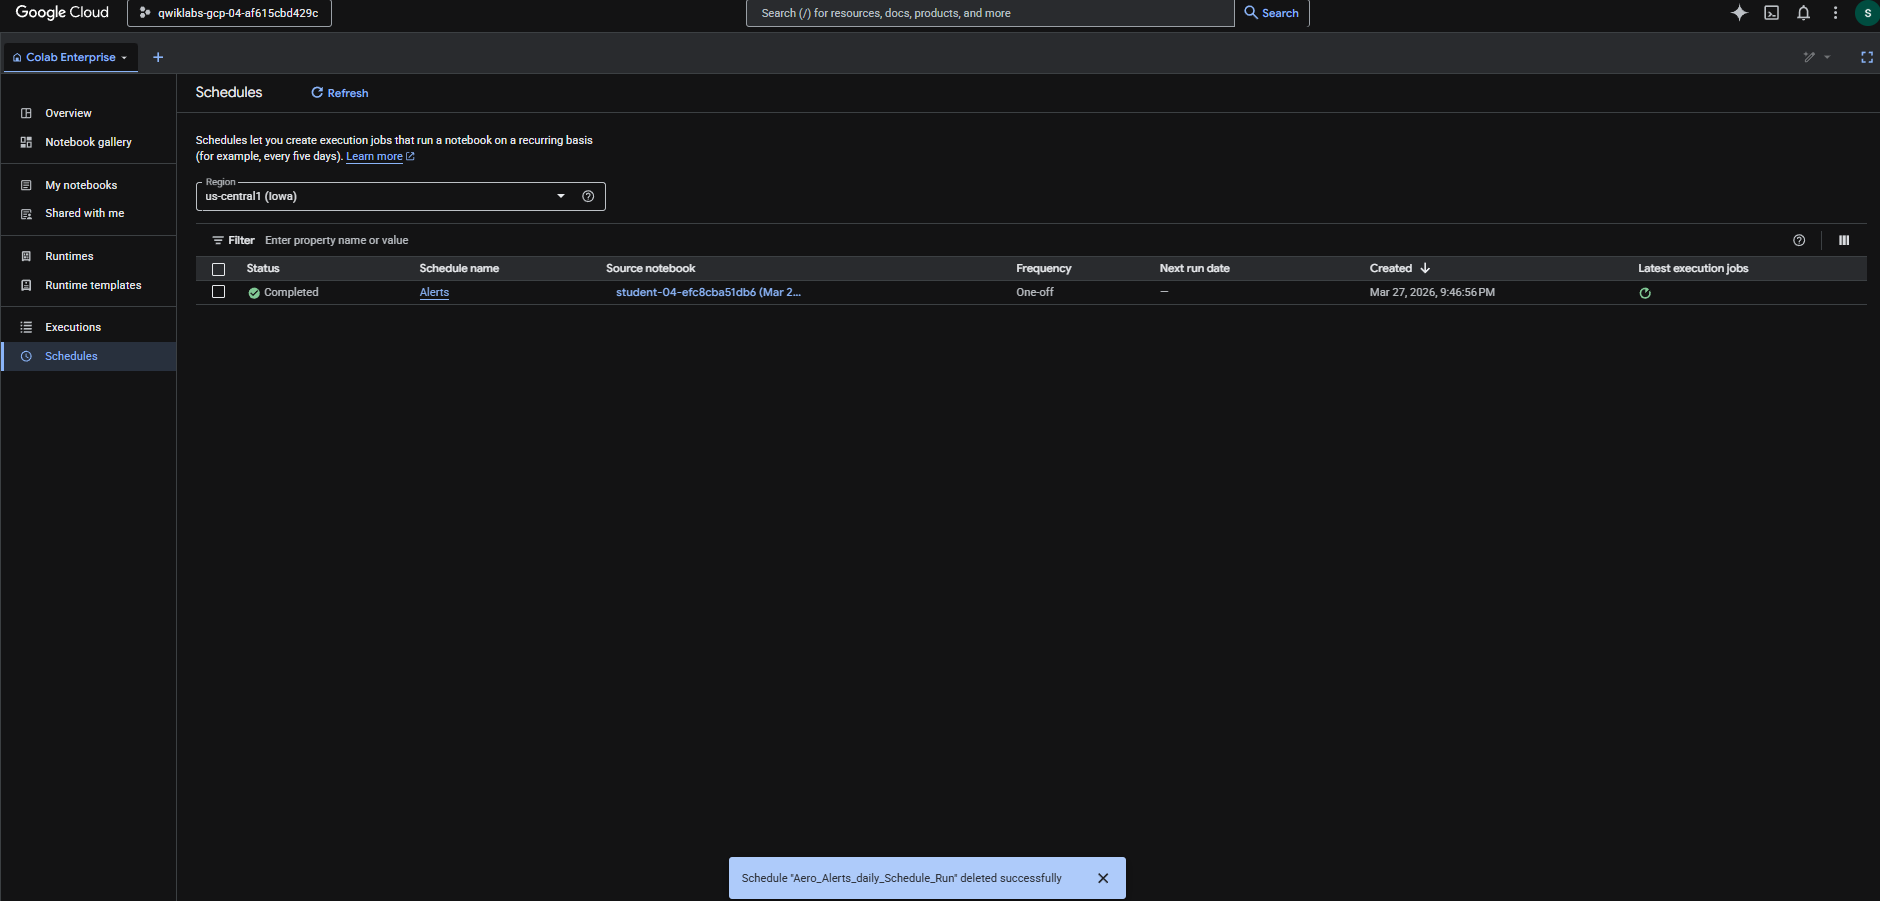